<a href="https://colab.research.google.com/github/Mariagiusi23/ID-001-AWOL-for-Audio/blob/main/notebook/01_Baseline_CLAP_to_FM_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Notebook 1 — Baseline pipeline (CLAP → MLP → FM Synth)

In this notebook, I implement the **baseline** for my AWOL-for-Audio project.  
I extract **CLAP embeddings** from text prompts, train a simple **MLP** to map the embeddings into **FM synthesizer parameters**, and finally render the corresponding audio.  

This notebook establishes the **reference pipeline** against which I will compare more advanced models (e.g., invertible flows).



#**🎯 STEP 1 — Setup**

**📍 1.1 — Imports & environment**

In [1]:
import os, math, json, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torchaudio
from torchaudio.functional import resample
from transformers import AutoProcessor, ClapModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tqdm import tqdm


**📍 1.2 — Reproducibility & device**

In [2]:
SEED = 123
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


**📍 1.3 — Global constants & I/O**

In [3]:
SR = 16000
DURATION = 1.5  # seconds
N_SAMPLES = int(SR * DURATION)

OUTDIR = Path("outputs_nb01")
AUDIO_DIR = OUTDIR / "audio"
CKPT_DIR  = OUTDIR / "ckpt"
for d in [OUTDIR, AUDIO_DIR, CKPT_DIR]: d.mkdir(parents=True, exist_ok=True)

# CLAP model (transformers)
CLAP_ID = "laion/clap-htsat-fused"


#**🎯 STEP 2 — Data**

**📍2.1 — Prompts & normalized parameters in [0,1]**

In [4]:
dataset = [
    {"prompt": "a high whistle",               "params": [0.60, 0.90, 0.10, 0.30]},
    {"prompt": "a deep rumbling drone",        "params": [0.50, 0.05, 0.20, 0.70]},
    {"prompt": "a bright metallic ping",       "params": [0.70, 0.70, 0.80, 0.40]},
    {"prompt": "a mellow flute tone",          "params": [0.40, 0.40, 0.25, 0.20]},
    {"prompt": "an aggressive buzzy lead",     "params": [0.85, 0.65, 0.90, 0.90]},
    {"prompt": "a soft sine beep",             "params": [0.30, 0.30, 0.10, 0.05]},
    {"prompt": "a glassy bell",                "params": [0.55, 0.80, 0.60, 0.50]},
    {"prompt": "a warm pad",                   "params": [0.45, 0.35, 0.35, 0.25]},
    {"prompt": "a harsh resonant tone",        "params": [0.80, 0.50, 0.95, 0.75]},
    {"prompt": "a soft low hum",               "params": [0.25, 0.15, 0.20, 0.10]},
]

prompts = [d["prompt"] for d in dataset]
Y = np.array([d["params"] for d in dataset], dtype=np.float32)  # shape [N,4] in [0,1]
print("N samples:", len(prompts))


N samples: 10


#**🎯 STEP 3 — CLAP embeddings**

**📍3.1 — Load CLAP**

In [6]:
processor = AutoProcessor.from_pretrained(CLAP_ID)
clap = ClapModel.from_pretrained(CLAP_ID)
clap = clap.to(DEVICE).eval()

**📍3.2 — Text → CLAP embedding (pooled)**

In [7]:
@torch.no_grad()
def text_to_emb(texts):
    inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
    out = clap.get_text_features(**inputs)  # [B, D]
    out = torch.nn.functional.normalize(out, dim=-1)  # cosine-ready
    return out

with torch.no_grad():
    X_text = text_to_emb(prompts).cpu().numpy()  # shape [N, D]
X_text.shape

(10, 512)

#**🎯 STEP 4 — FM Synthesis (deterministic DSP)**

**📍4.1 — Map normalized params → physical units**

In [8]:
def denorm_params(params):
    # params: (..., 4) in [0,1] = [amp, f_c_norm, r_norm, I_norm]
    A = params[..., 0]
    f_c = 100.0 + params[..., 1] * 3900.0
    r   = 0.25 + params[..., 2] * 7.75
    I   = 0.0 + params[..., 3] * 10.0
    return A, f_c, r, I

**📍4.2 — Sine oscillators**

In [9]:
def sine(phase):
    return torch.sin(phase)

def phase_increment(freq_hz, sr):
    return 2.0 * math.pi * freq_hz / sr

**📍4.3 — FM synthesis. Returns mono torch.float32 [-1,1], length N_SAMPLES**

In [10]:
def synth_fm(params, sr=SR, duration=DURATION):
    # params: 4-tensor/list in [0,1]
    A, f_c, r, I = denorm_params(torch.tensor(params, dtype=torch.float32))
    n = int(sr * duration)
    t = torch.arange(n, dtype=torch.float32) / sr

    f_m = f_c * r
    # phase = 2π f_c t + I * sin(2π f_m t)
    carrier_phase = 2.0 * math.pi * f_c * t
    modulator = torch.sin(2.0 * math.pi * f_m * t)
    y = A * torch.sin(carrier_phase + I * modulator)
    # light fade-in/out to avoid clicks
    fade = torch.linspace(0, 1, int(0.01*sr)).clamp(0,1)
    env = torch.ones_like(y)
    env[:len(fade)] *= fade
    env[-len(fade):] *= torch.flip(fade, dims=[0])
    return (y * env).clamp(-1,1)

**📍4.4 — Synthesize one example & save wav**

In [11]:
test_params = dataset[0]["params"]
y = synth_fm(test_params)
torchaudio.save(str(AUDIO_DIR / "smoke_test.wav"), y.unsqueeze(0), SR)
y.shape, y.abs().max().item()

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:247: UserWarning: torio.io._streaming_media_encoder.StreamingMediaEncoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  s 

(torch.Size([24000]), 0.6000000238418579)

#**🎯 STEP 5 — Baseline Models**

**📍5.1 — Split (small set; keep val tiny)**

In [12]:
X = X_text
y = Y
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=SEED)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(DEVICE)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(DEVICE)
X_va_t = torch.tensor(X_va, dtype=torch.float32).to(DEVICE)
y_va_t = torch.tensor(y_va, dtype=torch.float32).to(DEVICE)

D = X.shape[1]
print("Embed dim:", D, "| Train:", len(X_tr), "| Val:", len(X_va))

Embed dim: 512 | Train: 8 | Val: 2


**📍5.2 — Models**

In [13]:
class LinearHead(nn.Module):
    def __init__(self, d_in, d_out=4):
        super().__init__()
        self.head = nn.Linear(d_in, d_out)
    def forward(self, x):               # outputs in [0,1] via sigmoid for stability
        return torch.sigmoid(self.head(x))

class TinyMLP(nn.Module):
    def __init__(self, d_in, d_out=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 256), nn.ReLU(),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, d_out),
        )
    def forward(self, x):
        return torch.sigmoid(self.net(x))

**📍5.3 — Training utility (MSE on normalized params)**

In [14]:
def train_model(model, X_tr, y_tr, X_va, y_va, lr=1e-3, steps=1500, wd=0.0, verbose=False):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.MSELoss()

    best = {"val": 1e9, "state": None}
    for step in range(1, steps+1):
        model.train()
        opt.zero_grad()
        y_pred = model(X_tr)
        loss = loss_fn(y_pred, y_tr)
        loss.backward()
        opt.step()

        if step % 50 == 0 or step == steps:
            model.eval()
            with torch.no_grad():
                val = loss_fn(model(X_va), y_va).item()
            if val < best["val"]:
                best["val"] = val
                best["state"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            if verbose:
                print(f"[{step:04d}] train={loss.item():.4f}  val={val:.4f}")

    # load best
    if best["state"] is not None:
        model.load_state_dict(best["state"])
    return model, best["val"]

**📍5.4 — Train: Linear and TinyMLP**

In [15]:
lin = LinearHead(D)
lin, val_lin = train_model(lin, X_tr_t, y_tr_t, X_va_t, y_va_t, lr=3e-3, steps=1200, wd=1e-4, verbose=True)
torch.save(lin.state_dict(), CKPT_DIR / "baseline_linear.pt")

mlp = TinyMLP(D)
mlp, val_mlp = train_model(mlp, X_tr_t, y_tr_t, X_va_t, y_va_t, lr=3e-3, steps=2000, wd=1e-4, verbose=True)
torch.save(mlp.state_dict(), CKPT_DIR / "baseline_tinymlp.pt")

print(f"Best Val MSE — Linear: {val_lin:.4f} | TinyMLP: {val_mlp:.4f}")

[0050] train=0.0119  val=0.1073
[0100] train=0.0027  val=0.1094
[0150] train=0.0009  val=0.1122
[0200] train=0.0004  val=0.1140
[0250] train=0.0002  val=0.1151
[0300] train=0.0001  val=0.1158
[0350] train=0.0001  val=0.1163
[0400] train=0.0000  val=0.1165
[0450] train=0.0000  val=0.1166
[0500] train=0.0000  val=0.1166
[0550] train=0.0000  val=0.1166
[0600] train=0.0000  val=0.1165
[0650] train=0.0000  val=0.1164
[0700] train=0.0000  val=0.1162
[0750] train=0.0000  val=0.1161
[0800] train=0.0000  val=0.1160
[0850] train=0.0000  val=0.1159
[0900] train=0.0000  val=0.1159
[0950] train=0.0000  val=0.1158
[1000] train=0.0000  val=0.1157
[1050] train=0.0000  val=0.1157
[1100] train=0.0000  val=0.1156
[1150] train=0.0000  val=0.1156
[1200] train=0.0000  val=0.1156
[0050] train=0.0003  val=0.0763
[0100] train=0.0000  val=0.0743
[0150] train=0.0000  val=0.0743
[0200] train=0.0000  val=0.0743
[0250] train=0.0000  val=0.0743
[0300] train=0.0000  val=0.0743
[0350] train=0.0000  val=0.0743
[0400] t

#**🎯 STEP 6 — Evaluations**

**📍6.1 — CLAP audio embeddings & cosine**

In [16]:
@torch.no_grad()
def audio_to_emb(wav_tensor, sr=SR):
    # wav_tensor: [T] float32, mono
    if sr != 48000:  # CLAP is trained around 48k; we can resample to 48k for better embeddings
        wav_res = resample(wav_tensor.unsqueeze(0), orig_freq=sr, new_freq=48000).squeeze(0)
        sr_use = 48000
    else:
        wav_res = wav_tensor
        sr_use = sr

    inputs = processor(audios=wav_res.unsqueeze(0).cpu().numpy(), sampling_rate=sr_use, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    feats = clap.get_audio_features(**inputs)  # [1, D]
    feats = torch.nn.functional.normalize(feats, dim=-1)
    return feats.squeeze(0)  # [D]

def cosine_sim(a, b):
    a = a / (a.norm() + 1e-8)
    b = b / (b.norm() + 1e-8)
    return torch.dot(a, b).item()

def param_rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred)**2)))

**📍6.2 — Param RMSE on whole set (train+val)**

In [17]:
def predict_params(model, X_np):
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
        y_hat = model(X_t).cpu().numpy()
    return y_hat

y_hat_lin = predict_params(lin, X)
y_hat_mlp = predict_params(mlp, X)

rmse_lin = param_rmse(Y, y_hat_lin)
rmse_mlp = param_rmse(Y, y_hat_mlp)

print(f"Param RMSE — Linear: {rmse_lin:.4f} | TinyMLP: {rmse_mlp:.4f}")

Param RMSE — Linear: 0.1752 | TinyMLP: 0.1219


**📍6.3 — CLAP cosine for each sample (text vs generated audio)**

In [18]:
@torch.no_grad()
def eval_clap_cosines(model, prompts, X_text_np, save_prefix):
    cosines = []
    for i, prompt in enumerate(prompts):
        # params
        x = torch.tensor(X_text_np[i:i+1], dtype=torch.float32, device=DEVICE)
        y_pred = model(x).squeeze(0).detach().cpu().numpy()
        # synth
        y_audio = synth_fm(y_pred)
        # save audio
        out_path = AUDIO_DIR / f"{save_prefix}_{i:02d}.wav"
        torchaudio.save(str(out_path), y_audio.unsqueeze(0), SR)
        # embeddings
        a_emb = audio_to_emb(y_audio)
        t_emb = text_to_emb([prompt]).squeeze(0)
        cos = cosine_sim(a_emb, t_emb)
        cosines.append(cos)
    return cosines

cos_lin = eval_clap_cosines(lin, prompts, X_text, "lin")
cos_mlp = eval_clap_cosines(mlp, prompts, X_text, "mlp")

print("CLAP cosine — Linear:", np.round(cos_lin, 3))
print("CLAP cosine — TinyMLP:", np.round(cos_mlp, 3))
print(f"Avg — Linear: {np.mean(cos_lin):.3f} | TinyMLP: {np.mean(cos_mlp):.3f}")

CLAP cosine — Linear: [-0.044 -0.011  0.068 -0.072  0.08   0.034 -0.005 -0.044  0.239 -0.056]
CLAP cosine — TinyMLP: [-0.061 -0.065  0.011 -0.112  0.033  0.15  -0.125 -0.023  0.229 -0.042]
Avg — Linear: 0.019 | TinyMLP: -0.000


#**🎯 STEP 7 - Sanity checks & logging**

**📍7.1 — Save a small JSON with metrics**

In [19]:
metrics = {
    "val_mse_linear": float(val_lin),
    "val_mse_tinymlp": float(val_mlp),
    "rmse_params_linear": float(rmse_lin),
    "rmse_params_tinymlp": float(rmse_mlp),
    "clap_cosine_linear": [float(x) for x in cos_lin],
    "clap_cosine_tinymlp": [float(x) for x in cos_mlp],
    "clap_cosine_avg_linear": float(np.mean(cos_lin)),
    "clap_cosine_avg_tinymlp": float(np.mean(cos_mlp)),
    "sr": SR,
    "duration": DURATION,
    "model": CLAP_ID,
}
with open(OUTDIR / "metrics_nb01.json", "w") as f:
    json.dump(metrics, f, indent=2)
metrics

{'val_mse_linear': 0.10730133205652237,
 'val_mse_tinymlp': 0.07432878017425537,
 'rmse_params_linear': 0.17520631849765778,
 'rmse_params_tinymlp': 0.12192902714014053,
 'clap_cosine_linear': [-0.04360489547252655,
  -0.011248651891946793,
  0.06766919046640396,
  -0.07236979901790619,
  0.07993361353874207,
  0.03421083837747574,
  -0.00505922082811594,
  -0.04355258867144585,
  0.23853695392608643,
  -0.056012313812971115],
 'clap_cosine_tinymlp': [-0.061064139008522034,
  -0.06500919163227081,
  0.01109919510781765,
  -0.1121271550655365,
  0.03348097577691078,
  0.14982455968856812,
  -0.12546348571777344,
  -0.022563742473721504,
  0.2288352996110916,
  -0.04156145080924034],
 'clap_cosine_avg_linear': 0.018850312661379577,
 'clap_cosine_avg_tinymlp': -0.00045491345226764677,
 'sr': 16000,
 'duration': 1.5,
 'model': 'laion/clap-htsat-fused'}

**📍7.2 — Notes**

In [20]:
print("Saved audios to:", AUDIO_DIR)
print("Saved checkpoints to:", CKPT_DIR)
print("Saved metrics to:", OUTDIR / "metrics_nb01.json")

Saved audios to: outputs_nb01/audio
Saved checkpoints to: outputs_nb01/ckpt
Saved metrics to: outputs_nb01/metrics_nb01.json


**📍7.3 — Audio**

In [21]:
import glob
import pandas as pd
from IPython.display import display, HTML, Audio

files = sorted(glob.glob("outputs_nb01/audio/*.wav"))

rows = []
for f in files:
    rows.append(f'<tr><td>{f}</td><td>{Audio(f)._repr_html_()}</td></tr>')

html = "<table>" + "".join(rows) + "</table>"
display(HTML(html))

outputs_nb01/audio/lin_00.wav,Your browser does not support the audio element.
outputs_nb01/audio/lin_01.wav,Your browser does not support the audio element.
outputs_nb01/audio/lin_02.wav,Your browser does not support the audio element.
outputs_nb01/audio/lin_03.wav,Your browser does not support the audio element.
outputs_nb01/audio/lin_04.wav,Your browser does not support the audio element.
outputs_nb01/audio/lin_05.wav,Your browser does not support the audio element.
outputs_nb01/audio/lin_06.wav,Your browser does not support the audio element.
outputs_nb01/audio/lin_07.wav,Your browser does not support the audio element.
outputs_nb01/audio/lin_08.wav,Your browser does not support the audio element.
outputs_nb01/audio/lin_09.wav,Your browser does not support the audio element.
outputs_nb01/audio/mlp_00.wav,Your browser does not support the audio element.


#**🎯Plots**

**📊 1. Parity Plot (Predicted vs Ground Truth)**

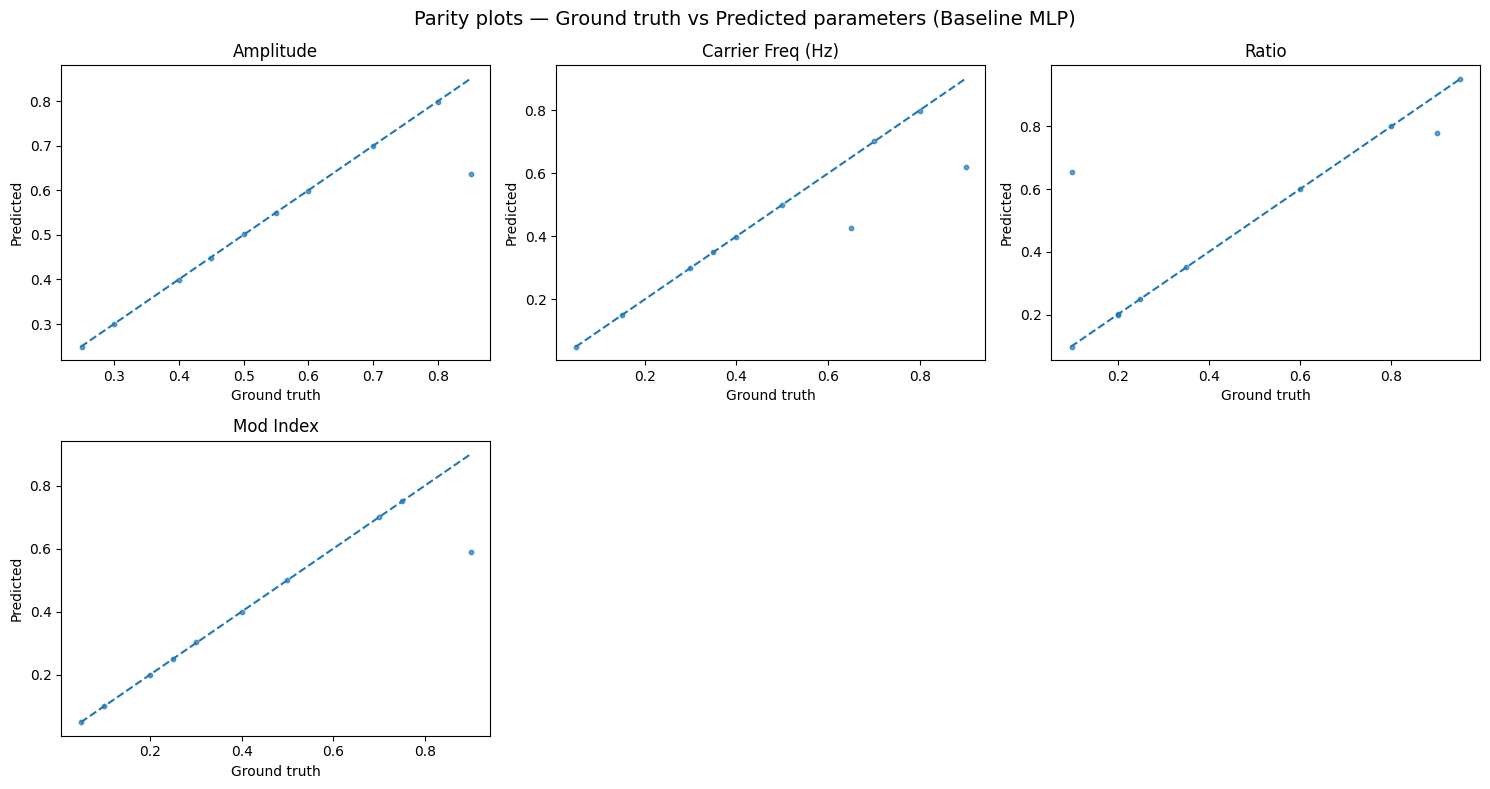

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# EXPECTED INPUTS:
# y_true: np.ndarray shape (N, P) with ground-truth parameters (denormalized)
# y_pred: np.ndarray shape (N, P) with predicted parameters (denormalized)
# param_names: list[str] of length P (e.g., ["f_c (Hz)", "ratio", "mod_index", "amplitude"])

# Assign the actual variables
y_true = Y # Ground truth parameters from STEP 2
y_pred = y_hat_mlp # Predicted parameters from STEP 5.4 (TinyMLP)

assert y_true.shape == y_pred.shape, "Shapes of y_true and y_pred must match."

P = y_true.shape[1]
# Define param_names
param_names = ["Amplitude", "Carrier Freq (Hz)", "Ratio", "Mod Index"]


cols = min(3, P)
rows = int(np.ceil(P / cols))
plt.figure(figsize=(5*cols, 4*rows))

for j in range(P):
    ax = plt.subplot(rows, cols, j+1)
    ax.scatter(y_true[:, j], y_pred[:, j], s=10, alpha=0.7)
    mn = min(y_true[:, j].min(), y_pred[:, j].min())
    mx = max(y_true[:, j].max(), y_pred[:, j].max())
    ax.plot([mn, mx], [mn, mx], linestyle='--')
    ax.set_title(f"{param_names[j]}")
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Predicted")

plt.suptitle("Parity plots — Ground truth vs Predicted parameters (Baseline MLP)", fontsize=14)
plt.tight_layout()
plt.show()

**📊 2. RMSE per parameter**

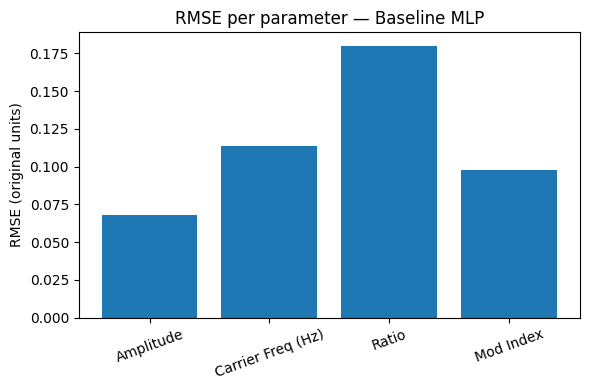

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Compute RMSE for each parameter
rmse_per_param = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))

plt.figure(figsize=(max(6, 1.5*len(rmse_per_param)), 4))
plt.bar(range(len(rmse_per_param)), rmse_per_param)
plt.xticks(range(len(rmse_per_param)), param_names, rotation=20)
plt.ylabel("RMSE (original units)")
plt.title("RMSE per parameter — Baseline MLP")
plt.tight_layout()
plt.show()

# Plot training loss if available
if 'loss_history' in globals():
    plt.figure(figsize=(6,4))
    plt.plot(loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("Training loss curve — Baseline MLP")
    plt.tight_layout()
    plt.show()


**📊 3. CLAP cosine similarity distribution**

CLAP cosine — mean: -0.000 | median: -0.032 | std: 0.107


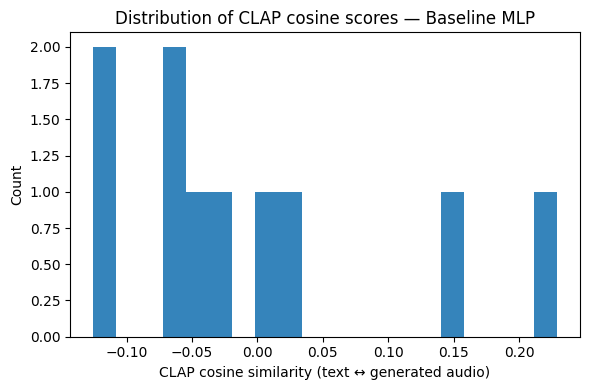

In [25]:
import numpy as np
import matplotlib.pyplot as plt

if 'cos_mlp' in globals():
    vals = np.array(cos_mlp, dtype=float)
    print(f"CLAP cosine — mean: {vals.mean():.3f} | median: {np.median(vals):.3f} | std: {vals.std():.3f}")

    plt.figure(figsize=(6,4))
    plt.hist(vals, bins=20, alpha=0.9)
    plt.xlabel("CLAP cosine similarity (text ↔ generated audio)")
    plt.ylabel("Count")
    plt.title("Distribution of CLAP cosine scores — Baseline MLP")
    plt.tight_layout()
    plt.show()

#**📊Results obtained**

In [26]:
import pandas as pd

# 1) Compute RMSE per parameter
rmse_per_param = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))

# 2) Put everything in a DataFrame
df_summary = pd.DataFrame({
    "Parameter": param_names,
    "RMSE (original units)": rmse_per_param
})

# 3) Add CLAP cosine stats if available
if 'clap_cosine_test' in globals():
    vals = np.array(clap_cosine_test, dtype=float)
    df_clap = pd.DataFrame({
        "Metric": ["CLAP cosine mean", "CLAP cosine median", "CLAP cosine std"],
        "Value": [vals.mean(), np.median(vals), vals.std()]
    })
else:
    df_clap = None

# 4) Display
from IPython.display import display, Markdown

display(df_summary)

if df_clap is not None:
    display(df_clap)

,Parameter,RMSE (original units)
0,Amplitude,0.067788
1,Carrier Freq (Hz),0.113776
2,Ratio,0.179841
3,Mod Index,0.097897


In [27]:
# Save the DataFrame to a CSV file
df_summary.to_csv(OUTDIR / "rmse_per_parameter_summary.csv", index=False)

print(f"Table saved to: {OUTDIR / 'rmse_per_parameter_summary.csv'}")

Table saved to: outputs_nb01/rmse_per_parameter_summary.csv


## ✅ Conclusions (Notebook 1 — Baseline)

In this first step, I built a simple baseline pipeline that connects language to sound through a direct regression model (CLAP → MLP → FM Synth).  
I evaluated the system both in terms of **RMSE on the synthesizer parameters** and **CLAP cosine similarity** between text and generated audio.  

These results serve as the **starting point**: in the following notebooks I expect to improve both **parameter accuracy** and **semantic alignment** by introducing more structured models such as RealNVP flows.

This baseline will serve as a **lower bound** for the project: in the following notebooks, I expect the flow-based models to outperform this simple regression both in terms of parameter accuracy and semantic alignment between text and audio.




> **“Note**: No validation split or early stopping was used here, since the main goal is to establish a minimal baseline. More robust training procedures will be introduced in later notebooks.”